In [1]:
%cd /content
!rm -rf ./dlfb-clone/
!git clone "https://github.com/deep-learning-for-biology/dlfb.git" dlfb-clone --branch main
%cd dlfb-clone

/content
Cloning into 'dlfb-clone'...
remote: Enumerating objects: 129, done.
remote: Counting objects: 100% (129/129), done.
remote: Compressing objects: 100% (95/95), done.
remote: Total 129 (delta 23), reused 115 (delta 17), pack-reused 0 (from 0)
Receiving objects: 100% (129/129), 63.15 KiB | 994.00 KiB/s, done.
Resolving deltas: 100% (23/23), done.
/content/dlfb-clone


In [2]:
%%bash
curl -LsSf https://astral.sh/uv/install.sh | sh && \
export PATH="/root/.local/bin:${PATH}" && \
uv pip compile ./requirements/{base,dlfb,proteins,gpu}.txt \
  --color never \
  --constraint ./requirements/constraints.txt | \
uv pip install -r - --system

installing to /usr/local/bin
  uv
  uvx
everything's installed!


downloading uv 0.11.22 x86_64-unknown-linux-gnu
Resolved 146 packages in 6.75s
Using Python 3.12.13 environment at: /usr
Resolved 146 packages in 1.31s
Prepared 70 packages in 56.25s
Uninstalled 53 packages in 4.07s
Installed 71 packages in 927ms
 - absl-py==1.4.0
 + absl-py==2.4.0
 + adjusttext==1.3.0
 + biopython==1.85
 - cachetools==6.2.6
 + cachetools==7.1.4
 - certifi==2026.5.20
 + certifi==2022.12.7
 - charset-normalizer==3.4.7
 + charset-normalizer==2.1.1
 + chex==0.1.90
 - click==8.4.1
 + click==8.1.8
 - cryptography==48.0.1
 + cryptography==49.0.0
 - datasets==4.0.0
 + datasets==2.19.1
 + dlfb==0.1.1 (from file:///content/dlfb-clone)
 - filelock==3.29.2
 + filelock==3.29.0
 - flax==0.11.2
 + flax==0.10.4
 - fsspec==2025.3.0
 + fsspec==2024.3.1
 - google-auth==2.47.0
 + google-auth==2.55.0
 - google-cloud-storage==3.11.0
 + google-cloud-storage==3.0.0
 - grpcio==1.81.0
 + grpcio==1.81.1
 - huggingface-hub==1.18.0
 + huggingface-hub==0.36.0
 - idna==3.18
 + idna==3.4
 + ipinfo==

In [3]:
!dlfb-provision --chapter proteins

Files Downloaded: 100% 22/22 [00:05<00:00,  4.03file/s]


In [4]:
# Toggle JAX_DISABLE_JIT to True for easier debugging
%env JAX_DISABLE_JIT=False

try:
  import dlfb
except ImportError as exc:
  # NOTE: Packages installed in editable mode are not immediately
  #       recognized by Colab (https://stackoverflow.com/a/63312333).
  import site
  site.main()
  import dlfb

from dlfb.utils.display import display

env: JAX_DISABLE_JIT=False


In [5]:
import pandas as pd
from dlfb.utils.context import assets
import py3Dmol
import requests

In [6]:
def download_pdb(pdb_id):
  path = f"https://files.rcsb.org/download/{pdb_id}.pdb"
  response = requests.get(path)
  return response.text

In [7]:
protein_to_pdb = {
  "insulin": "3I40",  # Human insulin – regulates glucose uptake.
  "collagen": "1BKV",  # Human collagen – provides structural support.
  "proteasome": "1YAR",  # Archaebacterial proteasome – degrades proteins.
}


In [8]:
protein = 'insulin'

fetched_protein = download_pdb(protein_to_pdb[protein])

In [9]:
view = py3Dmol.view(width=400, height=400)
view.addModel(fetched_protein, 'pdb')
view.setStyle({"cartoon": { "color": "spectrum"}})
view.zoomTo()
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [10]:
insulin_sequence = (
  "MALWMRLLPLLALLALWGPDPAAAFVNQHLCGSHLVEALYLVCGERGFFYTPKTRREAEDLQVGQVELGG"
  "GPGAGSLQPLALEGSLQKRGIVEQCCTSICSLYQLENYCN"
)
print(f"Length of the insulin protein precursor: {len(insulin_sequence)}.")

Length of the insulin protein precursor: 110.


In [14]:
from dlfb.utils.display import print_short_dict

# fmt: off
amino_acids = [
  "R", "H", "K", "D", "E", "S", "T", "N", "Q", "G", "P", "C", "A", "V", "I",
  "L", "M", "F", "Y", "W",
]

In [15]:
amino_acid_to_index = {amino_acid : index  for index, amino_acid in enumerate(amino_acids)}
print_short_dict(amino_acid_to_index)

{'R': 0, 'H': 1, 'K': 2, 'D': 3, 'E': 4, 'S': 5, 'T': 6, 'N': 7, 'Q': 8, 'G': 9}
…(+10 more entries)


In [16]:
tinny_protein = ["M", "A", "L", "W", "M"]

tinny_protein_index = [amino_acid_to_index[amino_acid] for amino_acid in tinny_protein]

tinny_protein_index

[16, 12, 15, 19, 16]

In [17]:
import jax

one_hot_encoded_sequence = jax.nn.one_hot(tinny_protein_index, num_classes=len(amino_acid_to_index))
one_hot_encoded_sequence

Array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.,
        0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
        0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        1., 0., 0., 0.]], dtype=float32)

In [1]:
from transformers import EsmModel, AutoTokenizer

In [2]:
checkpoint = 'facebook/esm2_t33_650M_UR50D'
tokenizer = AutoTokenizer.from_pretrained(checkpoint)
model = EsmModel.from_pretrained(checkpoint)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/724 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.61G [00:00<?, ?B/s]

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t33_650M_UR50D and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [3]:
vocab_to_index = tokenizer.get_vocab()
vocab_to_index

{'<cls>': 0,
 '<pad>': 1,
 '<eos>': 2,
 '<unk>': 3,
 'L': 4,
 'A': 5,
 'G': 6,
 'V': 7,
 'S': 8,
 'E': 9,
 'R': 10,
 'T': 11,
 'I': 12,
 'D': 13,
 'P': 14,
 'K': 15,
 'Q': 16,
 'N': 17,
 'F': 18,
 'Y': 19,
 'M': 20,
 'H': 21,
 'W': 22,
 'C': 23,
 'X': 24,
 'B': 25,
 'U': 26,
 'Z': 27,
 'O': 28,
 '.': 29,
 '-': 30,
 '<null_1>': 31,
 '<mask>': 32}

In [4]:
tokenized_tinny_protein = tokenizer('MALWM')['input_ids']

In [5]:
tokenized_tinny_protein[1:-1]

[20, 5, 4, 22, 20]

In [6]:
token_embedding = model.get_input_embeddings().weight.detach().numpy()
token_embedding.shape

(33, 1280)

In [7]:
insulin_sequence = (
  "MALWMRLLPLLALLALWGPDPAAAFVNQHLCGSHLVEALYLVCGERGFFYTPKTRREAEDLQVGQVELGG"
  "GPGAGSLQPLALEGSLQKRGIVEQCCTSICSLYQLENYCN"
)

masked_insulin_sequence = (
  "MALWMRLLPLLALLALWGPDPAAAFVNQH<mask>CGSHLVEALYLVCGERGFFYTPKTRREAEDLQVGQVELGG"
  "GPGAGSLQPLALEGSLQKRGIVEQCCTSICSLYQLENYCN"
)

In [8]:
from transformers import AutoTokenizer, EsmForMaskedLM

masked_input = tokenizer(masked_insulin_sequence)['input_ids']
len(masked_input)

112

In [9]:
model_checkpoint = "facebook/esm2_t33_650M_UR50D"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)
model = EsmForMaskedLM.from_pretrained(model_checkpoint)

In [10]:
model_output = model(
    **tokenizer(text=masked_insulin_sequence, return_tensors='pt')
)

print(len(model_output.logits[0]))

112


In [11]:
predicted = model_output.logits
print(predicted[0][30])

tensor([ -9.0646, -11.7896, -10.3126, -11.7551,   9.3161,  -2.1420,  -3.4099,
          0.5962,  -0.8429,  -3.7113,  -0.2798,  -2.7323,   0.4234,  -4.1830,
         -0.4291,  -3.0869,  -0.6170,  -3.4686,   1.4293,   0.2565,   0.2867,
         -0.6449,  -0.8070,  -4.4093,  -1.7407,  -9.7354,  -8.9224, -10.9110,
        -13.7902, -14.5937, -14.3059, -14.1723, -11.7599],
       grad_fn=<SelectBackward0>)


In [12]:
masked_pred = predicted[0,30].detach().numpy()
masked_pred

array([ -9.064646  , -11.789568  , -10.312554  , -11.755064  ,
         9.316057  ,  -2.1420436 ,  -3.4098678 ,   0.5962063 ,
        -0.8428867 ,  -3.7113183 ,  -0.27982056,  -2.7323415 ,
         0.42336568,  -4.1829515 ,  -0.42909575,  -3.0868685 ,
        -0.6169526 ,  -3.4686368 ,   1.4292907 ,   0.25647852,
         0.28674343,  -0.6449117 ,  -0.80700463,  -4.4093037 ,
        -1.7406871 ,  -9.73544   ,  -8.922359  , -10.911     ,
       -13.79016   , -14.593678  , -14.305877  , -14.172304  ,
       -11.759894  ], dtype=float32)

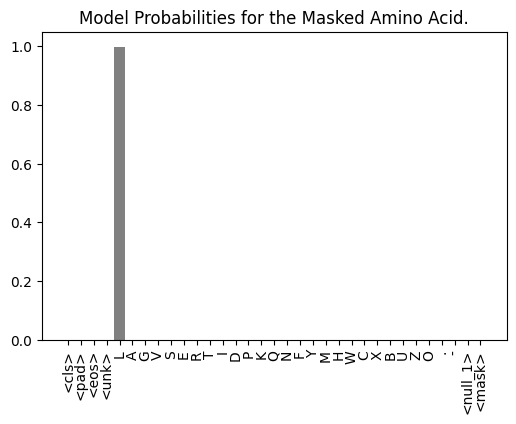

In [18]:
import matplotlib.pyplot as plt

masked_prob = jax.nn.softmax(masked_pred)
letters = list(vocab_to_index.keys())
fig, ax = plt.subplots(figsize=(6, 4))
plt.bar(letters, masked_prob, color="grey")
plt.xticks(rotation=90)
plt.title("Model Probabilities for the Masked Amino Acid.");


In [19]:
idx = masked_prob.argmax()
list(vocab_to_index.keys())[idx]

'L'

Create a class for this module

In [20]:
class MaskPredictor():
  def __init__(self, tokenizer, model):
    self.tokenizer = tokenizer
    self.model = model

  @staticmethod
  def mask_creator(input_sequence : str , mask_index: int) -> str:
    if mask_index < 0 or mask_index > len(input_sequence):
      raise ValueError("Mask index outside of sequence range.")
    return f"{input_sequence[0:mask_index]}<mask>{input_sequence[(mask_index + 1):]}"

  def predict(self, input_sequence : str , mask_index: int) -> jax.Array:
    input_masked = self.mask_creator(input_sequence, mask_index)
    masked_input = self.tokenizer(input_masked, return_tensors="pt")
    model_output = self.model(**masked_input)
    mask_pred = model_output.logits[0, mask_index + 1].detach().numpy()
    masked_prob = jax.nn.softmax(mask_pred)
    return masked_prob

In [21]:
mask_index = 26

In [22]:
model_output_pred = MaskPredictor(tokenizer, model).predict(input_sequence=insulin_sequence, mask_index=mask_index)

Text(0.5, 1.0, 'Model Probabilities for the Masked Amino Acid\nat Index=26 (True Amino Acid = N).')

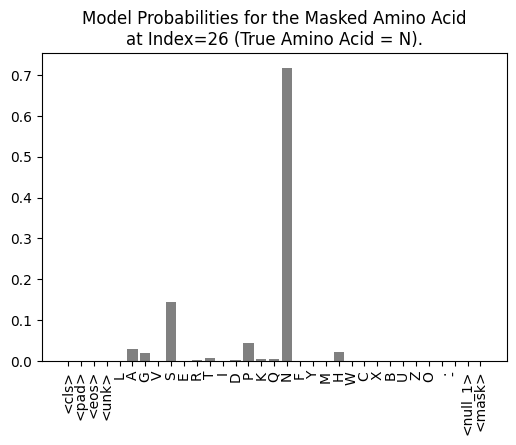

In [23]:
fig, _ = plt.subplots(figsize=(6, 4))
plt.bar(list(tokenizer.get_vocab().keys()), model_output_pred, color="grey")
plt.xticks(rotation=90)
plt.title(
  "Model Probabilities for the Masked Amino Acid\n"
  f"at Index={mask_index} (True Amino Acid = {insulin_sequence[mask_index]})."
)

In [24]:
import pandas as pd
from dlfb.utils.context import assets

protein_df = pd.read_csv(assets("proteins/datasets/sequence_df_cco.csv"))
protein_df.head()

,EntryID,Sequence,taxonomyID,term,aspect,Length
0,O95231,MRLSSSPPRGPQQLSSFGSVDWLSQSSCSGPTHTPRPADFSLGSLP...,9606,GO:0005622,CCO,258
1,O95231,MRLSSSPPRGPQQLSSFGSVDWLSQSSCSGPTHTPRPADFSLGSLP...,9606,GO:0031981,CCO,258
2,O95231,MRLSSSPPRGPQQLSSFGSVDWLSQSSCSGPTHTPRPADFSLGSLP...,9606,GO:0043229,CCO,258
3,O95231,MRLSSSPPRGPQQLSSFGSVDWLSQSSCSGPTHTPRPADFSLGSLP...,9606,GO:0043226,CCO,258
4,O95231,MRLSSSPPRGPQQLSSFGSVDWLSQSSCSGPTHTPRPADFSLGSLP...,9606,GO:0110165,CCO,258


remove "GO:0005575", "GO:0110165"

In [25]:
protein_df = protein_df[~protein_df['term'].isin(["GO:0005575", "GO:0110165"])]

In [26]:
num_proteins = protein_df['EntryID'].nunique()
print(num_proteins)

21457


In [27]:
num_locations = protein_df.groupby("EntryID")['term'].nunique()
num_locations

,term
EntryID,
A0A023T787,13
A0A024QYT6,8
A0A024QYX0,8
A0A024QYX2,16
A0A024QYX3,11
...,...
X6RKS3,15
X6RLN4,3
X6RLP6,11


In [28]:
proteins_one_location = num_locations[num_locations == 1].index
protein_df = protein_df[protein_df['EntryID'].isin(proteins_one_location)]
protein_df

,EntryID,Sequence,taxonomyID,term,aspect,Length
621,Q6N075,MLVTAYLAFVGLLASCLGLELSRCRAKPPGRACSNPSFLRFQLDFY...,9606,GO:0016020,CCO,450
3036,P01566,MALSFSLLMAVLVLSYKSICSLGCDLPQTHSLGNRRALILLGQMGR...,9606,GO:0005576,CCO,189
4648,Q86SQ6,MDLKTVLSLPRYPGEFLHPVVYACTAVMLLCLLASFVTYIVHQSAI...,9606,GO:0016020,CCO,560
4715,Q8IYM0,MEKDDPPQLVTPTSVKAIILRIEAAQLTRAQEDISTQLSDILDNVN...,9606,GO:0032991,CCO,893
5467,Q9NVL1,MAPEENAGSELLLQSFKRRFLAARALRSFRWQSLEAKLRDSSDSEL...,9606,GO:0032991,CCO,165
...,...,...,...,...,...,...
329726,A0A024RDS4,MDWGTLHTFIGGVNKHSTSIGKVWITVIFIFRVMILVVAAQEVWGD...,9606,GO:0030054,CCO,261
331823,Q5NV92,QLVLTQSPSASASLGASVKLTCTLSSGHSSYAIAWHQQQPEKGPRY...,9606,GO:0005576,CCO,99
331841,Q5NV81,QSVLTQPPSASGTPGQRVTISCSGSSSNIGSNTVNWYQQLPGTAPK...,9606,GO:0005576,CCO,99
332246,Q5NV68,QPVLTQPPSSSASPGESARLTCTLPSDINVGSYNIYWYQQKPGSPP...,9606,GO:0005576,CCO,104


In [29]:
go_function_examples = {
  "extracellular": "GO:0005576",
  "membrane": "GO:0016020",
}

In [43]:
function_by_sequences = {}

for function, term in go_function_examples.items():
  sequence = protein_df[(protein_df['term'] == term) & (protein_df['Length'] >= 100) & (protein_df['Length'] <= 500)]['Sequence']
  function_by_sequences[function] = list(sequence.sample(20, random_state=42))
  print(function)
  print(len(sequence))

extracellular
164
membrane
65


We’ll now extract embeddings from these sequences. The function
get_mean_embeddings computes the mean hidden state across each sequence,
summarizing the model’s representation of protein sequences

In [36]:
import torch
import numpy as np

In [51]:
def get_mean_embedding(sequences : list[str], tokenizer, model) -> np.ndarray:

  device = 'cuda' if torch.cuda.is_available() else 'cpu'
  model_input = tokenizer(sequences, padding=True, return_tensors='pt')
  model_input = {k : v.to(device) for k,v in model_input.items()}
  model = model.to(device)

  model.eval()

  with torch.no_grad():
    outputs = model(**model_input)
    mean_embedding = outputs.last_hidden_state.mean(dim=1)

  return mean_embedding.detach().cpu().numpy()


In [33]:
model_checkpoint = "facebook/esm2_t6_8M_UR50D"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)
model = EsmModel.from_pretrained(model_checkpoint)

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/775 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/31.4M [00:00<?, ?B/s]

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t6_8M_UR50D and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [52]:
protein_embeddings = {
  loc: get_mean_embedding(function_by_sequences[loc], tokenizer, model=model)
  for loc in ["extracellular", "membrane"]
}

# Reformat data.
labels, embeddings = [], []
for location, embedding in protein_embeddings.items():
  labels.extend([location] * embedding.shape[0])
  embeddings.append(embedding)
  print(f"{location}: {embedding.shape}")

extracellular: (20, 320)
membrane: (20, 320)


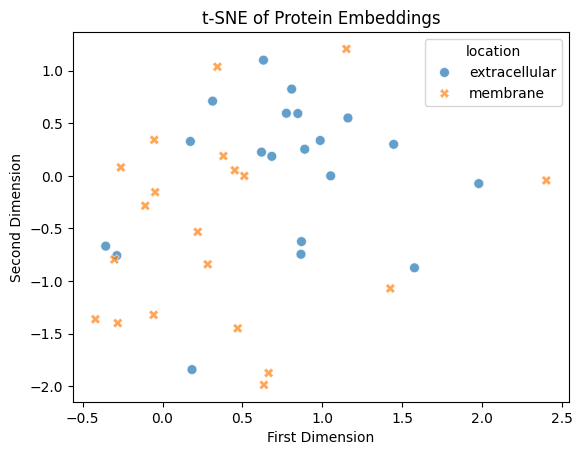

In [55]:
from sklearn.manifold import TSNE
import numpy as np
import seaborn as sns

embeddings_tsne = TSNE(n_components=2, random_state=42).fit_transform(np.vstack(embeddings))

embeddings_tsne_df = pd.DataFrame(
    {
        'first_dim' : embeddings_tsne[:,0],
        'second_dim' : embeddings_tsne[:,1],
        'location': np.array(labels)
    }
)


fig = sns.scatterplot(
  data=embeddings_tsne_df,
  x="first_dim",
  y="second_dim",
  hue="location",
  style="location",
  s=50,
  alpha=0.7,
)
plt.title("t-SNE of Protein Embeddings")
fig.set_xlabel("First Dimension")
fig.set_ylabel("Second Dimension");